Look at change rates of modern methane. Perhaps compare them to naive interpretation of paleo record.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hydra import initialize, compose
from pathlib import Path
from methane_noise_forcing.plotting.constants import matplotlib_rcparams, colors_vibrant, fig_width_options
plt.rcParams.update(matplotlib_rcparams)
plt.rcParams['figure.dpi'] = 200

# annual data (concentration)

In [2]:
## load data
with initialize(version_base=None, config_path="../../configs"):  # configs with data paths
    cfg = compose(config_name="config")
data_dir = Path(cfg.paths.observations_root)

obs_modern = pd.read_csv(data_dir / "raw" / "ch4_annmean_gl.csv", comment='#')

In [3]:
# calculate change over some lag
lag = 5
obs_modern["ch4_change"] = obs_modern["mean"].diff(periods=lag)

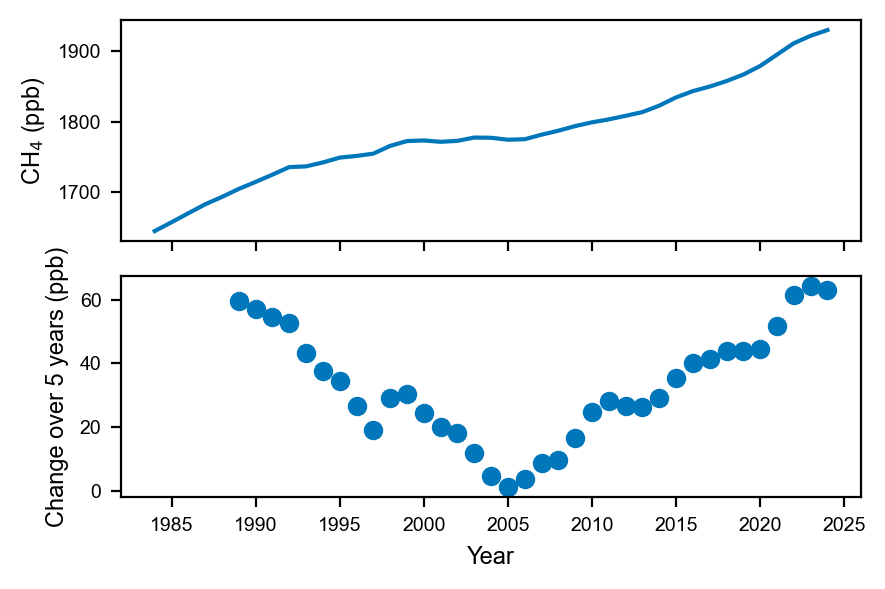

In [4]:
# plot obs and change
fig, axs = plt.subplots(2, 1, figsize=(fig_width_options["two_column_small"], 3), sharex=True)

axs[0].plot(obs_modern["year"], obs_modern["mean"], color=colors_vibrant["blue"])
axs[0].set_ylabel("CH$_4$ (ppb)")

axs[1].plot(obs_modern["year"], obs_modern["ch4_change"], linestyle="", marker='o', color=colors_vibrant["blue"])
axs[1].set_ylabel(f"Change over {lag} years (ppb)")
axs[1].set_xlabel("Year")

plt.tight_layout()

In [5]:
## detrend linearly
ceoffs = np.polyfit(obs_modern["year"].dropna(), obs_modern["mean"].dropna(), deg=1)
trend = np.polyval(ceoffs, obs_modern["year"])
obs_modern["mean_detrended"] = obs_modern["mean"] - trend
obs_modern["ch4_change_detrended"] = obs_modern["mean_detrended"].diff(periods=lag)
ceoffs

array([ 5.68261324e+00, -9.60470059e+03])

Text(0.5, 0, 'Year')

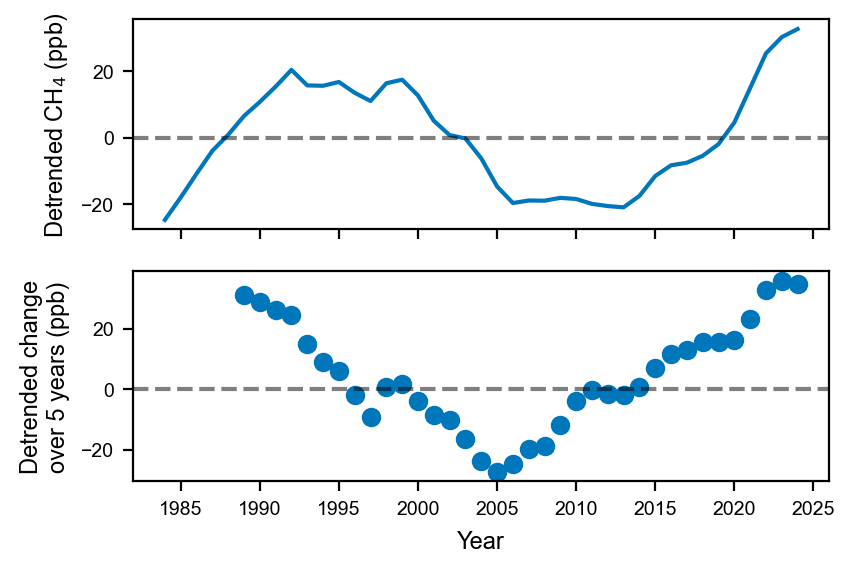

In [6]:
# plot detrended obs and change
fig, axs = plt.subplots(2, 1, figsize=(fig_width_options["two_column_small"], 3), sharex=True)

axs[0].plot(obs_modern["year"], obs_modern["mean_detrended"], color=colors_vibrant["blue"])
axs[0].axhline(0, color='k', linestyle='--', alpha=0.5)
axs[0].set_ylabel("Detrended CH$_4$ (ppb)")

axs[1].plot(obs_modern["year"], obs_modern["ch4_change_detrended"], linestyle="", marker='o', color=colors_vibrant["blue"])
axs[1].axhline(0, color='k', linestyle='--', alpha=0.5)
axs[1].set_ylabel(f"Detrended change\nover {lag} years (ppb)")
axs[1].set_xlabel("Year")

## save detrended data

In [7]:
# save data
obs_modern_to_save = obs_modern[["year", "mean", "mean_detrended"]].dropna()
obs_modern_to_save = obs_modern_to_save.rename(columns={
    "mean": "ch4",
    "mean_detrended": "ch4_detrended"
})
save_dir = Path(cfg.paths.observations_cultivated)
obs_modern_to_save.to_csv(save_dir / "ch4_modern_detrended.csv", index=False)

# annual data (growth rate)

In [ ]:
obs_gr_modern = pd.read_csv(data_dir / "raw" / "ch4_gr_gl.csv", comment='#')
obs_gr_modern = obs_gr_modern.rename(columns={"ann inc": "ch4_growth"})
# remove mean to detrend
obs_gr_modern["ch4_growth_detrended"] = obs_gr_modern["ch4_growth"] - obs_gr_modern["ch4_growth"].mean()

Text(0.5, 0, 'Year')

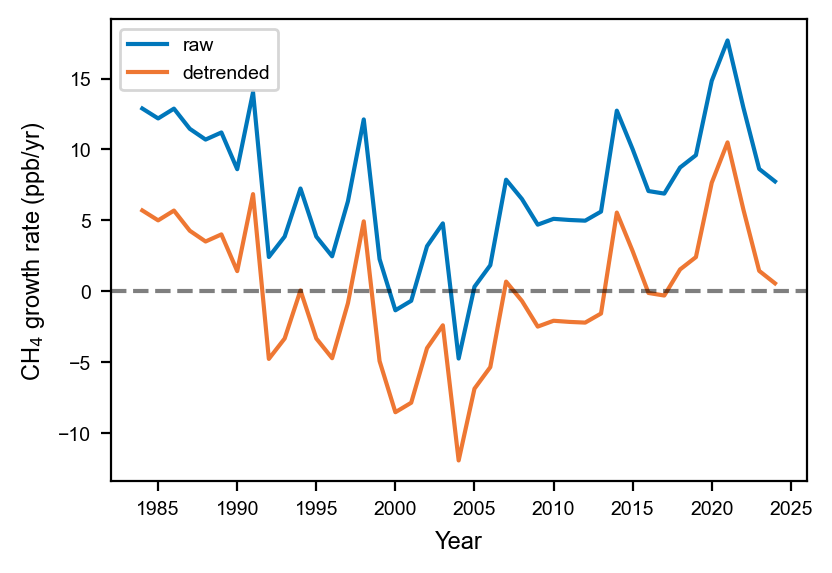

In [21]:
## plot growth rate
fig, ax = plt.subplots(1, 1, figsize=(fig_width_options["two_column_small"], 3))
ax.plot(obs_gr_modern["year"], obs_gr_modern["ch4_growth"], color=colors_vibrant["blue"], label="raw")
ax.plot(obs_gr_modern["year"], obs_gr_modern["ch4_growth_detrended"], color=colors_vibrant["orange"], label="detrended")
ax.axhline(0, color='k', linestyle='--', alpha=0.5)
ax.legend()
ax.set_ylabel("CH$_4$ growth rate (ppb/yr)")
ax.set_xlabel("Year")

In [22]:
## save detrended data
obs_gr_modern_to_save = obs_gr_modern[["year", "ch4_growth", "ch4_growth_detrended"]].dropna()
save_dir = Path(cfg.paths.observations_cultivated)
obs_gr_modern_to_save.to_csv(save_dir / "ch4_growth_modern_detrended.csv", index=False)

# Monthly data

In [8]:
## load data
obs_monthly = pd.read_csv(data_dir / "raw" / "ch4_mm_gl.csv", comment='#')

# change year and month columns to fractional year
obs_monthly["year_frac"] = obs_monthly["year"] + (obs_monthly["month"] - 1) / 12

obs_monthly_clean = obs_monthly[["year_frac", "month", "average"]].dropna()
obs_monthly_clean = obs_monthly_clean.rename(columns={
    "year_frac": "year",
    "average": "ch4"
})

2 methods of detrending and removing the seasonality:
1. removing the bulk trend, then removing the seasonal cycle
2. removing the trend in each month separately

In [9]:
## method 1: detrend then remove seasonal cycle
# remove long-term trend
ceoffs = np.polyfit(obs_monthly_clean["year"].dropna(), obs_monthly_clean["ch4"].dropna(), deg=1)
trend = np.polyval(ceoffs, obs_monthly_clean["year"])
obs_monthly_clean["ch4_detrended"] = obs_monthly_clean["ch4"] - trend

# remove seasonal cycle
# calculate monthly climatology
monthly_climatology = obs_monthly_clean.groupby("month")["ch4_detrended"].mean().reset_index()
monthly_climatology = monthly_climatology.rename(columns={"ch4_detrended": "climatology"})
# merge with original data
obs_monthly_clean = obs_monthly_clean.merge(monthly_climatology, on="month", how="left")
# remove climatology
obs_monthly_clean["ch4_anomaly_1"] = obs_monthly_clean["ch4_detrended"] - obs_monthly_clean["climatology"]

## method 2: remove trend in each month separately
for month in range(1, 13):
    mask = (obs_monthly_clean["month"] == month)
    ceoffs = np.polyfit(obs_monthly_clean.loc[mask, "year"].dropna(), obs_monthly_clean.loc[mask, "ch4"].dropna(), deg=1)
    trend = np.polyval(ceoffs, obs_monthly_clean.loc[mask, "year"])
    obs_monthly_clean.loc[mask, "ch4_anomaly_2"] = obs_monthly_clean.loc[mask, "ch4"] - trend

Text(0.5, 0, 'Year')

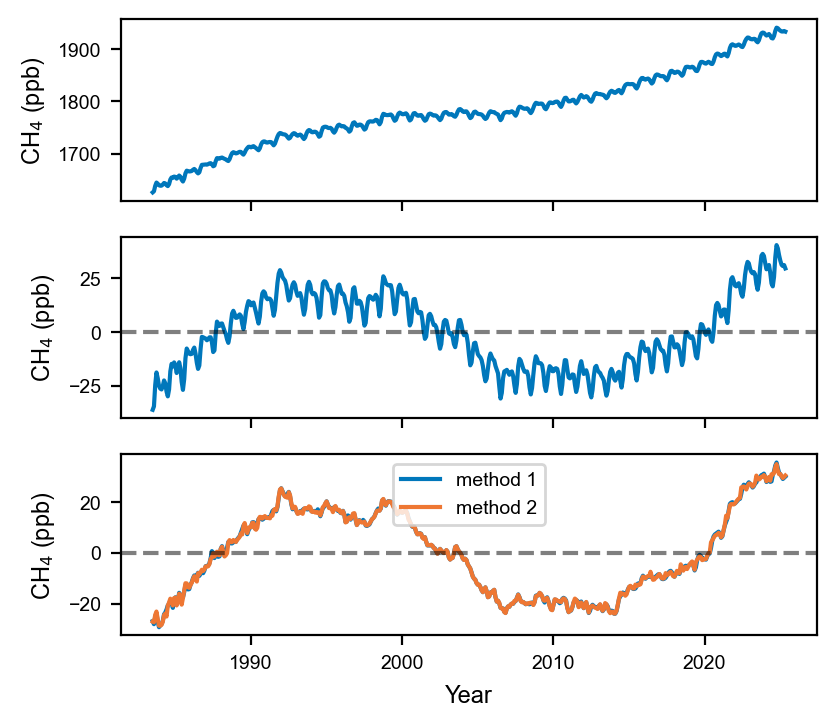

In [10]:
## plot original data, detrended, and anomaly
fig, axs = plt.subplots(3, 1, figsize=(fig_width_options["two_column_small"], 4), sharex=True)
axs[0].plot(obs_monthly_clean["year"], obs_monthly_clean["ch4"], color=colors_vibrant["blue"])
axs[0].set_ylabel("CH$_4$ (ppb)")
axs[1].plot(obs_monthly_clean["year"], obs_monthly_clean["ch4_detrended"], color=colors_vibrant["blue"])
axs[1].set_ylabel("CH$_4$ (ppb)")
axs[1].axhline(0, color='k', linestyle='--', alpha=0.5)
axs[2].plot(obs_monthly_clean["year"], obs_monthly_clean["ch4_anomaly_1"], color=colors_vibrant["blue"], label="method 1")
axs[2].plot(obs_monthly_clean["year"], obs_monthly_clean["ch4_anomaly_2"], color=colors_vibrant["orange"], label="method 2")
axs[2].axhline(0, color='k', linestyle='--', alpha=0.5)
axs[2].legend()
axs[2].set_ylabel("CH$_4$ (ppb)")
axs[2].set_xlabel("Year")

In [11]:
## choose method 2
obs_monthly_clean["ch4_anomaly"] = obs_monthly_clean["ch4_anomaly_2"]
obs_monthly_clean = obs_monthly_clean.drop(columns=["ch4_anomaly_1", "ch4_anomaly_2"])

In [12]:
## calculate change over some lag
lag = 1 # 1 month
obs_monthly_clean["ch4_change"] = obs_monthly_clean["ch4_anomaly"].diff(periods=lag)

Text(0.5, 0, 'Year')

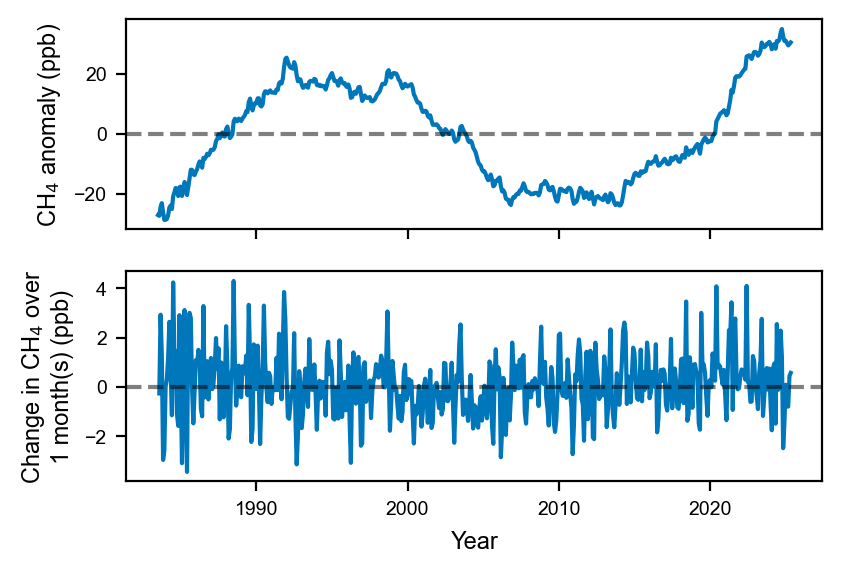

In [13]:
## plot obs and change
fig, axs = plt.subplots(2, 1, figsize=(fig_width_options["two_column_small"], 3), sharex=True)
axs[0].plot(obs_monthly_clean["year"], obs_monthly_clean["ch4_anomaly"], color=colors_vibrant["blue"])
axs[0].axhline(0, color='k', linestyle='--', alpha=0.5)
axs[0].set_ylabel("CH$_4$ anomaly (ppb)")
axs[1].plot(obs_monthly_clean["year"], obs_monthly_clean["ch4_change"], color=colors_vibrant["blue"])
axs[1].axhline(0, color='k', linestyle='--', alpha=0.5)
axs[1].set_ylabel(f"Change in CH$_4$ over\n{lag} month(s) (ppb)")
axs[1].set_xlabel("Year")

In [14]:
## save monthly data
obs_monthly_to_save = obs_monthly_clean[["year", "month", "ch4", "ch4_anomaly"]].dropna()
obs_monthly_to_save.to_csv(save_dir / "ch4_modern_monthly_detrended.csv", index=False)